<a href="https://colab.research.google.com/github/BadhonPain/AI_ML/blob/ML/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1️⃣ Data Loading & Exploration**

In [1]:
import pandas as pd

In [19]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]
df = pd.read_csv(url, names= columns)

In [20]:

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
df.shape

(768, 9)

In [26]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
df.count()

,0
Pregnancies,768
Glucose,768
BloodPressure,768
SkinThickness,768
Insulin,768
BMI,768
DiabetesPedigreeFunction,768
Age,768
Outcome,768


In [27]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


# **2️⃣ Data Preprocessing**

In [18]:
from sklearn.model_selection import train_test_split

In [37]:
X = df.drop("Outcome",axis= 1);
y = df["Outcome"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **3️⃣ Model Training & Evaluation**

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [61]:
results = {}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    print(f"Evaluation Metrices of {name}: ")
    accuracy = accuracy_score(Y_test, y_pred)
    print(f"Accuracy Score : {accuracy:.4f}")
    precision = precision_score(Y_test, y_pred)
    print(f"Precision Score : {precision:.4f}")
    recall = recall_score(Y_test, y_pred)
    print(f"Recall Score : {recall:.4f}")
    f1 = f1_score(Y_test, y_pred)
    print(f"F1 Score : {f1:.4f}")
    auc = roc_auc_score(Y_test, y_pred)
    print(f"ROC_AUC Score : {auc:.4f}")
    print("============================================")

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    }

Evaluation Metrices of Logistic Regression: 
Accuracy Score : 0.7468
Precision Score : 0.6379
Recall Score : 0.6727
F1 Score : 0.6549
ROC_AUC Score : 0.7303
Evaluation Metrices of Decision Tree: 
Accuracy Score : 0.7468
Precision Score : 0.6250
Recall Score : 0.7273
F1 Score : 0.6723
ROC_AUC Score : 0.7424
Evaluation Metrices of Random Forest: 
Accuracy Score : 0.7208
Precision Score : 0.6071
Recall Score : 0.6182
F1 Score : 0.6126
ROC_AUC Score : 0.6980
Evaluation Metrices of KNN: 
Accuracy Score : 0.6623
Precision Score : 0.5246
Recall Score : 0.5818
F1 Score : 0.5517
ROC_AUC Score : 0.6444


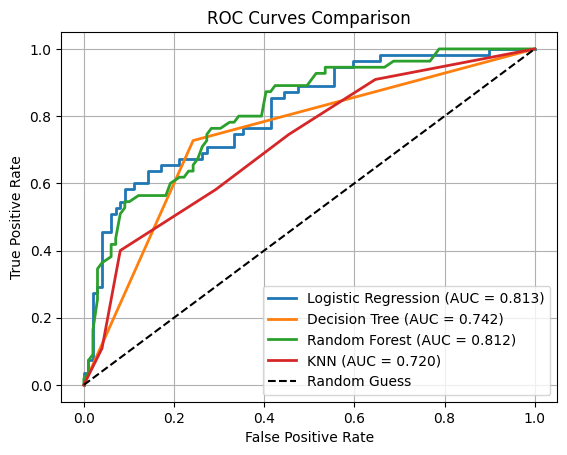

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    # ROC
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    auc = roc_auc_score(Y_test, y_prob)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# **Comparison and Best Model FInding**

In [71]:
# Comparison
comparison = pd.DataFrame(results).T
comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.746753,0.637931,0.672727,0.654867,0.730303
Decision Tree,0.746753,0.625000,0.727273,0.672269,0.742424
Random Forest,0.720779,0.607143,0.618182,0.612613,0.697980
KNN,0.662338,0.524590,0.581818,0.551724,0.644444


In [72]:
# Choosing best model
best_model_name = comparison["ROC AUC"].idxmax()

print(f"Best Model: {best_model_name}")

Best Model: Decision Tree


In [78]:
pip install joblib

In [79]:
import joblib

In [80]:
best_model = models[best_model_name]
joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']